In [ ]:
# default_exp core.baseline

In [ ]:
# hide
from nbdev.showdoc import *

In [ ]:
# export
import scipy.sparse as sparse
from scipy.sparse import linalg
from numpy.linalg import norm
import numpy as np
import scipy.interpolate as interp
from scipy import ndimage
from scipy import optimize
from hifast.utils.misc import average_every_n, smooth1d, smooth1d_fft

import os
import warnings
warnings.filterwarnings("ignore", r'overflow encountered in exp')

In [ ]:
# export
def get_baseline(x, ys, axis=None, *,
                 s_method='none', s_sigma=3, average_every=None, exclude=None,
                 method='arPLS', bl_para=None,
                 verbose=False, return_f=False, check=True):
    """
    subtract the baseline of spectra with XX and YY polar.
    Parameters：
    ---------------
    x: array, shape (n,); freq or vel.
    ys: array, T or Jy
    axis: axis along fitting baseline
    s_sigma, s_method: if s_sigma is not 'none', smoothing ys along axis using s_method ('gaussian' or 'boxcar')
    average_every: int; if set as n and n>1, then average ys along axis every n points
    return_f: If Fasle, return baseline, else return (basline, ys_processed, x_processed, weights)
    """
    if exclude is not None:
        if exclude.shape != ys.shape:
            raise(ValueError('exclude should has same shape with ys'))
    # check if ys is one dim
    if ys.ndim == 1:
        ys = ys[:, None]
        if exclude is not None:
            exclude = exclude[:, None]
        ch = True
        axis = 0
    else:
        ch = False

    # smooth ys along axis
    if s_method is not None and s_method != 'none':
        if s_method in ['boxcar', 'gaussian', 'median']:
            ys = smooth1d(ys, s_method, s_sigma, axis=axis)
        elif s_method == 'fft':
            ys = smooth1d_fft(x, ys, s_sigma, axis=axis)
        else:
            raise(ValueError('not support the method'))
    else:
        ys = ys

    if average_every is not None and average_every > 1:
        drop = False
        x_ori = x
        x = average_every_n(x, average_every, drop=drop)
        ys = average_every_n(ys, average_every, axis=axis, drop=drop)
        if exclude is not None:
            exclude = average_every_n(
                exclude, average_every, axis=axis, drop=drop).astype('bool')
    # after smooth(average), check nan, posinf, neginf
    if check:
        is_finite = np.isfinite(ys)
        if not is_finite.all():
            # replace value as 0 and add to exclude
            ys = np.copy(ys)
            ys[~is_finite] = np.max(ys[is_finite])
            if exclude is not None:
                exclude = exclude | (~is_finite)
            else:
                exclude = ~is_finite
        del is_finite
    # select baseline method
    method_dict = {'arPLS': BL_arPLS,
                   'srPLS': BL_srPLS,
                   'asPLS': BL_asPLS,
                   'masPLS': BL_masPLS,
                   'Chebyshev': BL_Chebyshev,
                   'poly': BL_poly,
                   'sin_poly': BL_sin_poly,
                   'sin_poly_2': BL_sin_poly,
                   }
    if method == 'original':
        return ys
    if method in ['arPLS', 'srPLS', 'asPLS', 'masPLS']:
        if 'sym' in bl_para.keys():
            bl_para = bl_para.copy()  # shallow copy
            del bl_para['sym']
        if bl_para['deg'] > 3:
            warnings.warn('deg is too large in PLS methods and has been set to 4.')
            bl_para['deg'] = 3 # bl_para has been shallow copyed
        use_x = False
    elif method in ['Chebyshev', 'poly', 'sin_poly', 'sin_poly_2']:
        use_x = True
    else:
        raise(ValueError('method does not support'))
    BL = method_dict[method](**bl_para)
    # move axis to last
    ys = np.moveaxis(ys, axis, -1)
    if exclude is not None:
        exclude = np.moveaxis(exclude, axis, -1)
    shape_bak = ys.shape
    # ys = ys.reshape((-1,shape_bak[-1])) #will copy the data
    # or np.apply_along_axis
    bls = np.zeros_like(ys)
    if return_f:
        weis = np.zeros_like(ys, dtype=np.float32)
    if verbose:
        from tqdm import tqdm
        iter_ = tqdm(np.ndindex(
            *(shape_bak[:-1])), total=ys.size/shape_bak[-1], desc='CPU 0: ', mininterval=2)
    else:
        iter_ = np.ndindex(*(shape_bak[:-1]))

    for ii in iter_:
        y = ys[ii + np.s_[:, ]]
        if exclude is not None:
            _exclude = exclude[ii + np.s_[:, ]]
        else:
            _exclude = None
        if use_x:
            bl = BL.fit(x, y, _exclude)
        else:
            bl = BL.fit(y, _exclude)
        bls[ii + np.s_[:, ]] = bl
        if return_f:
            weis[ii + np.s_[:, ]] = BL.wei
    # move back
    bls = np.moveaxis(bls, -1, axis)
    if return_f:
        weis = np.moveaxis(weis, -1, axis)
    if average_every is not None and average_every > 1:
        bls = interp.interp1d(x, bls, axis=axis, kind='linear',
                              fill_value='extrapolate')(x_ori)
    if return_f:
        # move back
        ys = np.moveaxis(ys, -1, axis)
        if ch:
            return bls[:, 0], ys[:, 0], x, weis[:, 0]
        else:
            return bls, ys, x, weis
    else:
        if ch:
            return bls[:, 0]
        else:
            return bls


def get_baseline_mp(n, x, ys, *, exclude=None,  **kwargs):
    """
    testing...
    only support axis=1,
    not support return_f=True
    """
    if 'axis' in kwargs.keys():
        if kwargs['axis'] != 1:
            raise(ValueError('get_baseline_mp only support axis=1 for now'))
    else:
        kwargs['axis'] = 1
    n = min(n, len(ys))
    from functools import partial
    from multiprocessing import Process, Queue

    def get_baseline_q(q, *args, **kwargs):
        res = get_baseline(*args, **kwargs)
        q.put(res)
    ps = []
    qs = []
    if exclude is not None:
        exclude_list = np.array_split(exclude, n)
    else:
        exclude_list = [None, ] * n
    ys_list = np.array_split(ys, n)
    for ys, exclude in zip(ys_list, exclude_list):
        q = Queue()
        p = Process(target=get_baseline_q, args=(q, x, ys),
                    kwargs={'exclude': exclude, **kwargs})
        if 'verbose' in kwargs.keys():
            kwargs['verbose'] = False

        ps += [p]
        qs += [q]
    for p in ps:
        p.start()
    res = np.vstack([q.get()for q in qs])
    for p in ps:
        p.join()  # need after q.get()
    return np.stack(res)

In [ ]:
# export
class BL_arPLS(object):
    """
    (automatic) Baseline correction using asymmetrically reweighted penalized least squares smoothing. 
                     Baek et al. 2015, Analyst 140: 250-257
    Parameters
    ----------
    lam:
    offset:
    deg:
    ratio:
    niter:
    """

    def __init__(self, lam=10**12, offset=2, deg=3, ratio=0.01, niter=100, rew=True):
        self.lam = lam
        self.offset = offset
        self.deg = deg
        self.ratio = ratio
        self.niter = niter
        if not rew:
            self.niter = 1

    def _reweight(self, d):
        # make d- and get w^t with m and s
        dn = d[d < 0]
        m = np.mean(dn)
        s = np.std(dn)
        wt = 1.0/(1 + np.exp(2 * (d-(self.offset*s-m))/s))
        return wt

    def fit(self, y, exclude=None, wei=None):
        # Adaptation of the Matlab code in Baek et al 2015 and python code in https://github.com/charlesll/rampy
        N = len(y)
        D = sparse.csc_matrix(sparse.eye(N))
        #D= self._diff(D)
        def diff_fun(x): return x[:, 1:] - \
            x[:, :-1]  # x is a csc sparse matrix
        for i in range(self.deg):
            D = diff_fun(D)
        w = np.ones(N) if wei is None else np.copy(wei)
        if exclude is not None:
            w[exclude] = 0
        H = D.dot(D.transpose()).multiply(self.lam)
        for i in range(self.niter):
            W = sparse.spdiags(w, 0, N, N)
            Z = W + H
            z = linalg.spsolve(Z, w*y)
            d = y - z
            wt = self._reweight(d)
            if exclude is not None:
                wt[exclude] = 0
            # check exit condition and backup
            ratio_fit = norm(w-wt)/norm(w)
            if ratio_fit < self.ratio:
                break
            w = wt

        bl = z
        self.success = True if ratio_fit <= self.ratio else False
        self.wei = w
        return bl


class BL_srPLS(BL_arPLS):
    def _reweight(self, d):
        dn = abs(d)
        m = np.mean(dn)/3
        s = np.std(dn)/3
        wt = 1.0/(np.exp(2 * (abs(d)-(self.offset*s-m))/s))
        return wt

In [ ]:
# export
class BL_base(object):
    """
    (automatic) Baseline fit
    Parameters
    ----------
    offset:
    deg:
    ratio:
    niter:
    """

    def __init__(self, offset=2, deg=3, ratio=0.01, niter=100, rew=True, sym=False):
        self.offset = offset
        self.deg = deg
        self.ratio = ratio
        self.niter = niter
        self.rew = rew
        self._reweight = self._reweight_s if sym else self._reweight_a

    def _reweight_a(self, d):
        # make d- and get w^t with m and s
        dn = d[d < 0]
        m = np.mean(dn)
        s = np.std(dn)
        wt = 1.0/(1 + np.exp(2 * (d-(self.offset*s-m))/s))
        return wt

    def _reweight_s(self, d):
        dn = abs(d)
        m = np.mean(dn)/3
        s = np.std(dn)/3
        wt = 1.0/(np.exp(2 * (abs(d)-(self.offset*s-m))/s))
        return wt

    def _fit(self, x, y, w):
        return y

    def fit(self, x, y, exclude=None, wei=None):
        N = len(y)
        w = np.ones(N) if wei is None else np.copy(wei)
        if exclude is not None:
            w[exclude] = 0
        for i in range(self.niter):
            z = self._fit(x, y, w)
            if not self.rew:
                break
            d = y - z
            wt = self._reweight(d)
            if exclude is not None:
                wt[exclude] = 0
            # check exit condition and backup
            ratio_fit = norm(w-wt)/norm(w)
            if ratio_fit < self.ratio:
                break
            w = wt
        bl = z
        if self.rew:
            self.success = True if ratio_fit <= self.ratio else False
        self.wei = w
        return bl


class BL_Chebyshev(BL_base):
    """
    (automatic) Baseline correction using Chebyshev fit
    Parameters
    ----------
    offset:
    deg:
    ratio:
    niter:
    """

    def pred(self, x):
        return np.polynomial.chebyshev.chebval(x, self.para)

    def _fit(self, x, y, w):
        para = np.polynomial.chebyshev.chebfit(x, y, self.deg, w=w)
        self.para = para
        return self.pred(x)


class BL_poly(BL_base):
    """
    (automatic) Baseline correction using polynomial fit
    Parameters
    ----------
    offset:
    deg:
    ratio:
    niter:
    """

    def pred(self, x):
        return np.polynomial.polynomial.polyval(x, self.para)

    def _fit(self, x, y, w):
        para = np.polynomial.polynomial.polyfit(x, y, self.deg, w=w)
        self.para = para
        return self.pred(x)


class BL_sin_poly(BL_base):
    """
    (automatic) Baseline correction using sin plus poly
    Parameters
    ----------
    offset:
    deg:
    ratio:
    niter:
    """

    def __init__(self, f, ptype='poly', opt_para={}, **kwarg):
        super().__init__(**kwarg)
        if np.isscalar(f):
            f = [f]
        self.f = f
        self.ptype = ptype
        self.set_opt_para(**opt_para)

    def _fun(self, x, *arg):
        arg = np.asarray(arg)
        coef = arg[-(self.deg + 1):]
        y = np.zeros_like(x)
        for _A, _f, _p in zip(*np.split(arg[:-(self.deg + 1)], 3)):
            y += _A*np.sin(2*np.pi*_f*x + _p)
        if self.ptype == 'poly':
            y += np.polynomial.polynomial.polyval(x, coef)
        elif 'cheb' in self.ptype.lower():
            y += np.polynomial.chebyshev.chebval(x, coef)
        return y

    def _err_func(self, para, x, y, w):
        residuals = y-self._fun(x, *para)
        return np.sum((residuals*w)**2, dtype='float64')

    def set_opt_para(self, method='Powell', **kwarg):
        """
        scipy.optimize.minimize parameter
        """
        self.opt_method = method
        self.opt_kwarg = kwarg

    def _fit(self, x, y, w):
        nsin = len(self.f)
        self.w = w
        std = np.std(y[w >= 0.99])
        p0 = [std] + [std/2]*(nsin-1)
        p0 += self.f + [0, ]*nsin
        p0 += [0]*(self.deg+1)

        #err_func = self._err_func(x, y, w, *arg)
        res = optimize.minimize(self._err_func, p0, args=(
            x, y, w), method=self.opt_method, **self.opt_kwarg)
        self.para = res.x
        self.fit_res = res
        return self._fun(x, *res.x)

    def pred(self, x):
        return self._fun(x, *self.para)


class BL_sin_poly_2(BL_sin_poly):
    """
    (automatic) Baseline correction using sin plus poly
    Parameters
    ----------
    offset:
    deg:
    ratio:
    niter:
    """

    def set_opt_para(self, **kwarg):
        """
        scipy.optimize.curve_fit parameter
        """
        self.opt_kwarg = kwarg

    def _fit(self, x, y, w):
        nsin = len(self.f)
        self.w = w
        std = np.std(y[w >= 1])
        p0 = [std] + [std/2]*(nsin-1)
        p0 += self.f + [0, ]*nsin
        p0 += [0]*(self.deg+1)

        res = optimize.curve_fit(
            self._fun, x, y, p0, sigma=1./w, **self.opt_kwarg)

        self.para = res[0]
        self.fit_res = res
        return self._fun(x, *self.para)

In [ ]:
# export
class BL_asPLS(BL_arPLS):
    """
    (automatic) Baseline correction using a modified version of adaptive smoothness parameter penalized least squares method. 
        Feng Zhang et al. 2020, DOI: 10.1080/00387010.2020.1730908

    Parameters
    ----------
    lam:
    offset:
    deg:
    ratio:
    niter:
    """

    def _reweight(self, d):
        # make d- and get w^t with m and s
        dn = d[d < 0]
        s = np.std(dn, ddof=1)
        wt = 1.0/(1 + np.exp(self.offset * (d-s)/s))
        return wt

    def _update_alpha(self, d):
        d_abs = np.abs(d)
        return d_abs/np.max(d_abs)

    def fit(self, y, exclude=None, wei=None):
        N = len(y)
        D = sparse.csc_matrix(sparse.eye(N))
        #D= self._diff(D)

        def diff_fun(x): return x[:, 1:] - \
            x[:, :-1]  # x is a csc sparse matrix
        for i in range(self.deg):
            D = diff_fun(D)
        w = np.ones(N) if wei is None else np.copy(wei)
        alpha = np.ones(N)
        if exclude is not None:
            w[exclude] = 0
        H = D.dot(D.transpose()).multiply(self.lam)
        for i in range(self.niter):
            W = sparse.spdiags(w, 0, N, N)
            Z = W + H.multiply(alpha[:, None])
            z = linalg.spsolve(Z, w*y)
            d = y - z
            wt = self._reweight(d)
            if exclude is not None:
                wt[exclude] = 0
            # check exit condition and backup
            ratio_fit = norm(w-wt)/norm(w)
            if ratio_fit < self.ratio:
                break
            w = wt
            alpha = self._update_alpha(d)

        bl = z
        self.success = True if ratio_fit <= self.ratio else False
        self.wei = w
        return bl

In [ ]:
# export
class BL_masPLS(BL_asPLS, BL_arPLS):
    def _reweight(self, *args, **kwargs):
        return BL_arPLS._reweight(self, *args, **kwargs)

In [ ]:
import h5py
from matplotlib import pyplot as plt

In [ ]:
fname = '../test/M33/data/M33_OTF_1_MultiBeamOTF-M02_W-20210731-specs_T-bld.hdf5'

f = h5py.File(fname, 'r')

f.keys()

<KeysViewHDF5 ['Header', 'Ta', 'Tcal', 'dec', 'freq', 'is_delay', 'is_extrapo', 'is_on', 'mjd', 'next_to_cal', 'ra']>

In [ ]:
# 如果 mjd 不是 顺序，先 按时间排序，
ind_sort = np.argsort(f['mjd'])
T2p = f['Ta'][()][ind_sort]
freq = f['freq'][()]

frange = (1300, 1430)
is_ = (freq > frange[0]) & (freq < frange[1])
freq = freq[is_]
T2p = T2p[:, is_, :]

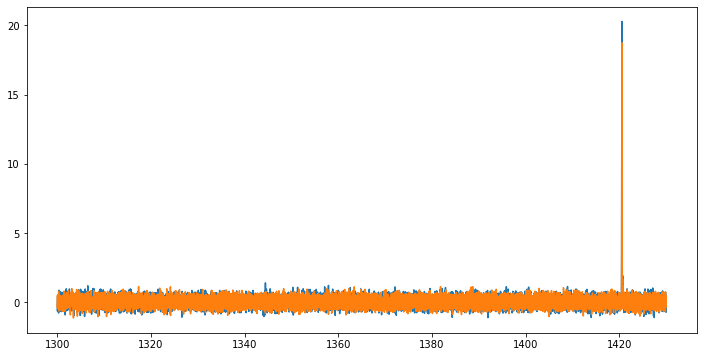

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(freq, T2p[200])

(17039, 2)


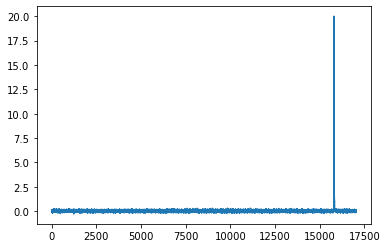

In [ ]:
spec = np.mean(T2p[200:220], axis=0, dtype='float64')
print(spec.shape)

# 用 XX 偏振
spec = spec[:, 0]
plt.plot(spec)

(-0.5, 1.0)

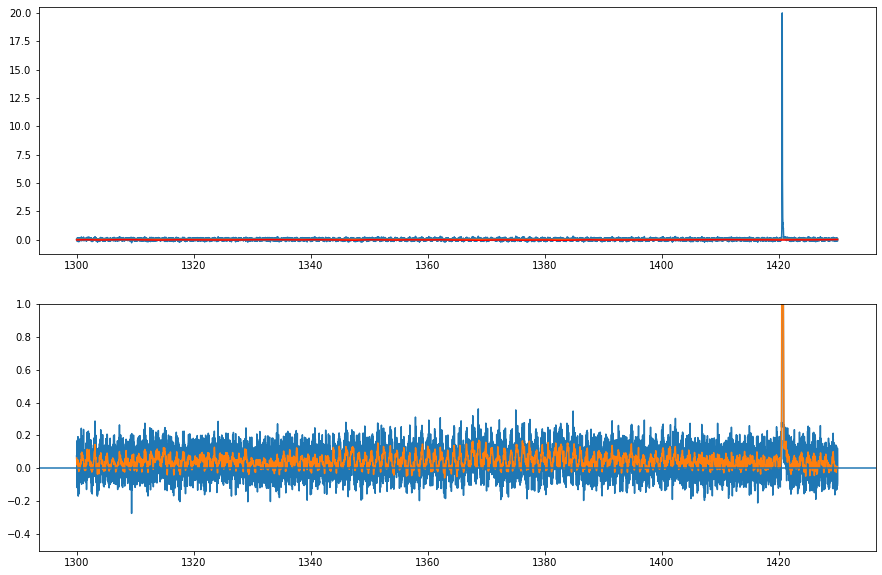

In [ ]:
# fit
method = 'arPLS'
bl_para = {}
bl_para['lam'] = 1e8
bl_para['deg'] = 2
bl_para['niter'] = 400
bl_para['ratio'] = 0.001

fig, axs = plt.subplots(2, 1, figsize=(15, 10),)
bl1 = get_baseline(freq, spec, axis=0, average_every=3,
                   method=method, bl_para=bl_para, verbose=False)
method = 'asPLS'
bl_para['lam'] = 1e8
#bl_para['offset']= 1.8
bl2 = get_baseline(freq, spec, axis=0, average_every=3,
                   method=method, bl_para=bl_para, verbose=False)
# plot Polar XX
ax = axs[0]
ax.plot(freq, spec)
ax.plot(freq, bl1)
ax.plot(freq, bl2, 'r')
ax.set_ylim(top=20.5)
# plot baselined YY and YY
ax = axs[1]
ax.plot(freq, spec-bl2)
ax.plot(freq, ndimage.gaussian_filter1d(spec-bl2, 3))
ax.axhline(y=0)
ax.set_ylim(-0.5, 1)

In [ ]:
# # fit
# method = 'arPLS'
# bl_para = {}
# bl_para['lam'] = 1e7
# bl_para['deg'] = 2
# bl_para['niter'] = 400
# bl_para['ratio'] = 0.001

# fig, axs = plt.subplots(2, 1, figsize=(15, 10),)
# bl1 = get_baseline(freq, spec, axis=0, average_every=2,
#                    method=method, bl_para=bl_para, verbose=False)
# method = 'asPLS'
# bl_para['lam'] = 1e8
# bl2 = pybaselines.whittaker.aspls(spec, lam=1e7, max_iter=200,)[0]
# # plot Polar XX
# ax = axs[0]
# ax.plot(freq, spec)
# ax.plot(freq, bl1)
# ax.plot(freq, bl2, 'r')
# # plot baselined YY and YY
# ax = axs[1]
# ax.plot(freq, spec-bl2)
# ax.plot(freq, ndimage.gaussian_filter1d(spec-bl2, 3))
# ax.axhline(y=0)
# ax.set_ylim(-0.5, 1)

CPU 0: 100%|██████████| 1/1.0 [00:01<00:00,  1.24s/it]


(1300.0, 1340.0)

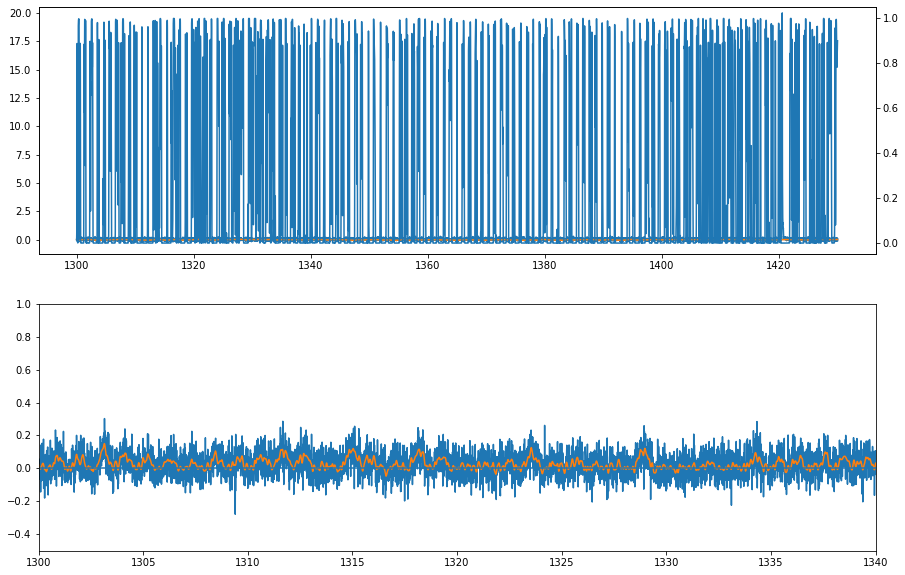

In [ ]:
# fit
method = 'asPLS'
bl_para = {}
bl_para['lam'] = 1e8
bl_para['deg'] = 2
bl_para['niter'] = 400
bl_para['ratio'] = 0.01

s_method = 'gaussian'  # 'fft'
s_sigma = 5

fig, axs = plt.subplots(2, 1, figsize=(15, 10),)
bl1_res = get_baseline(freq, spec, axis=0, average_every=None, method=method, bl_para=bl_para,
                       s_method=s_method, s_sigma=s_sigma,
                       verbose=True, return_f=True,)
bl1 = bl1_res[0]
# plot Polar XX
ax = axs[0]
ax.plot(freq, spec)
ax.plot(freq, bl1)
#ax.plot(freq, bl1_res[1])
ax.set_ylim(top=20.5)
ax = ax.twinx()
ax.plot(freq, bl1_res[3])
# plot baselined YY and YY
ax = axs[1]
ax.plot(freq, spec-bl1)
ax.plot(freq, ndimage.gaussian_filter1d(spec-bl1, 4))
ax.axhline(y=0)
ax.set_ylim(-0.5, 1)
ax.set_xlim(1300, 1340)

CPU 0: 100%|██████████| 1/1.0 [00:01<00:00,  1.37s/it]


(1300.0, 1340.0)

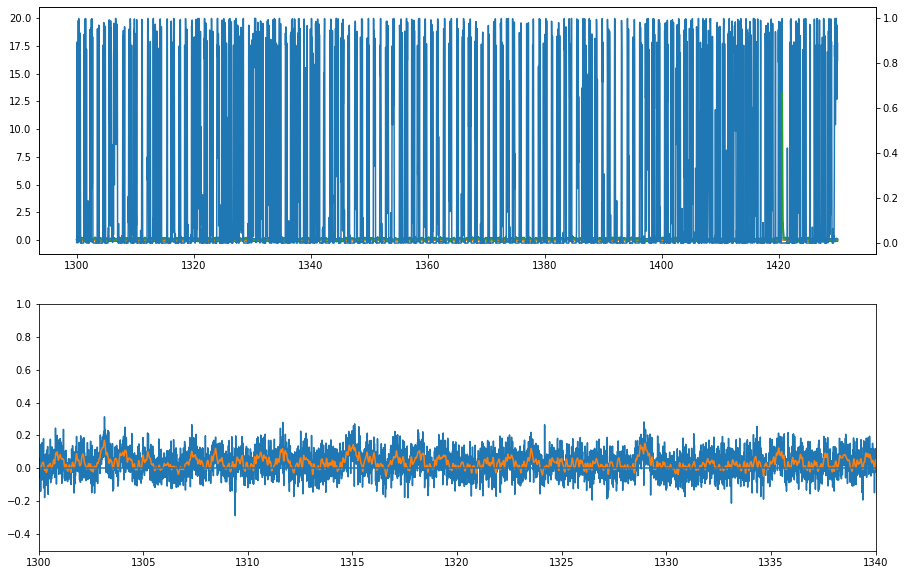

In [ ]:
# fit
method = 'asPLS'
bl_para = {}
bl_para['lam'] = 1e8
bl_para['deg'] = 2
bl_para['niter'] = 400
bl_para['ratio'] = 0.01

s_method = 'gaussian'  # 'fft'
s_sigma = 3

fig, axs = plt.subplots(2, 1, figsize=(15, 10),)
bl1_res = get_baseline(freq, spec, axis=0, average_every=None, method=method, bl_para=bl_para,
                       s_method=s_method, s_sigma=s_sigma,
                       verbose=True, return_f=True,)
bl1 = bl1_res[0]
# plot Polar XX
ax = axs[0]
ax.plot(freq, spec)
ax.plot(freq, bl1)
ax.plot(freq, bl1_res[1])
ax = ax.twinx()
ax.plot(freq, bl1_res[3])
# plot baselined YY and YY
ax = axs[1]
ax.plot(freq, spec-bl1)
ax.plot(freq, ndimage.gaussian_filter1d(spec-bl1, 3))
ax.axhline(y=0)
ax.set_ylim(-0.5, 1)
ax.set_xlim(1300, 1340)

In [ ]:
# class SubBaseline():
#     def __init__(self, freq, njoin, method, para, exclude_fun=None, s_method_t=None, s_sigma_t=3, verbose=True, nproc=1):
#         """
#         freq: array, shape:(n,) ; Frequency.
#         yss: array, shape:(m,n,2)
#         njoin: int
#         method: str; baseline fitting method
#         para: dict; para for method
#         exclude_fun:
#         s_method_t: smooth method along axis 0
#         s_sigma_t:


#         """
#         self.freq = freq
#         self.njoin = njoin
#         self.method = method
#         self.para = para
#         self.exclude_fun = exclude_fun
#         self.s_method_t = s_method_t
#         self.s_sigma_t = s_sigma_t
#         self.verbose = verbose
#         self.nproc = nproc
#     def

In [ ]:
# export
def sub_baseline(freq, yss, *, nproc=1, exclude_fun=None, inplace=False, 
                 njoin=1, s_method_t='none', s_sigma_t=None,
                 method='arPLS', s_method_freq='none', s_sigma_freq=None, average_every_freq=None,
                 lam=1e8, deg=2, offset=2, ratio=0.01, niter=100, sin_f=[0.925, ], rew=True, opt_para=None,
                 verbose=True,
                 ):
    """
    freq: array, shape:(n,) ; Frequency.
    yss: array, shape:(m,n,2)

    njoin: int
    nproc:
    exclude_fun:
    s_method_t: smooth method along axis 0
    s_sigma_t:
    s_method_freq:
    s_sigma_freq:
    average_every_freq:
    method: str; baseline fitting method
    bl_para: baseline fitting parameter
    verbose:
    """
    # check
    if yss.ndim != 3:
        raise(ValueError('yss should has 3-dim'))
    if yss.shape[1] != len(freq):
        raise(ValueError('the 2nd dimension of yss should equal to the length of freq'))
    
    # baseline fit parameter
    bl_para = {
        'deg': deg,
        'offset': offset,
        'ratio': ratio,
        'niter': niter,
        'rew': rew,
    }
    if method in ['arPLS', 'asPLS', 'srPLS', 'masPLS']:
        bl_para['lam'] = lam
    if 'sin' in method:
        bl_para['f'] = sin_f
        if opt_para is not None:
            bl_para['opt_para'] = opt_para
        

    yss_ori = yss
    # smooth spectra along t
    if s_method_t is not None and s_method_t != 'none':
        if s_method_t in ['boxcar', 'gaussian', 'median']:
            yss = smooth1d(yss, s_method_t, s_sigma_t, axis=0)
        elif s_method_t == 'fft':
            yss = smooth1d_fft(np.arange(yss.shape[0]), yss, s_sigma_t, axis=0)
        else:
            raise(ValueError('not support the method'))
    # join
    if njoin is not None and njoin > 1:
        yss = average_every_n(yss, njoin, axis=0, drop=False)
    # add exclude
    if exclude_fun is not None:
        exclude = exclude_fun(yss)
    else:
        exclude = None

    if s_method_freq == 'PLS':
        # use arPLS, lam from s_sigma ( s_sigma_freq)
        yss = get_baseline_mp(nproc, freq, yss, axis=1, method='arPLS', bl_para={
                               'lam': para['s_sigma'], "offset": 2, 'deg': 2}, verbose=verbose)
        s_method_freq = None
    #get baseline
    bls = get_baseline_mp(nproc, freq, yss, axis=1, exclude=exclude, s_method=s_method_freq, s_sigma=s_sigma_freq, average_every=average_every_freq,
                          method=method, bl_para=bl_para, verbose=verbose)

    if njoin is not None and njoin > 1:
        return yss_ori - bls[np.searchsorted(np.arange(0,yss_ori.shape[0],njoin), 1+np.arange(yss_ori.shape[0]))-1]
    else:
        return yss_ori - bls

In [ ]:
T = sub_baseline(freq, T2p_t, nproc=10, exclude_fun=None,
                 njoin=3, s_method_t='none', s_sigma_t=3,
                 method='arPLS', s_method_freq='gaussian', s_sigma_freq=3, average_every_freq=None,
                 lam=1e8, deg=2, offset=2, ratio=0.01, niter=100, sin_f=[0.925, ],
                 verbose=True,
                 )

CPU 0: 100%|██████████| 14/14.0 [00:01<00:00, 10.90it/s]


(1413.0, 1414.0)

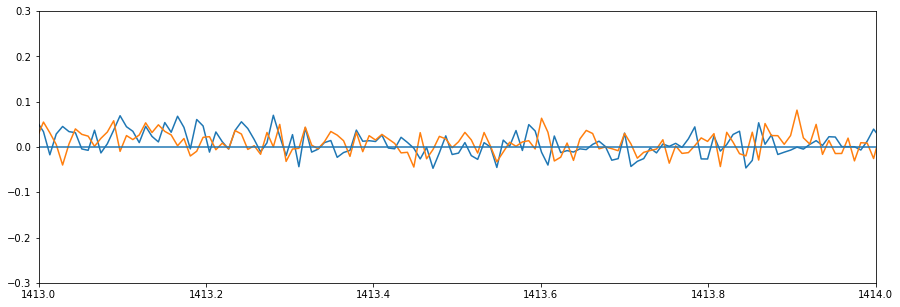

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(freq, np.mean(T, axis=0))
plt.axhline(y=0)
plt.ylim(-0.3, 0.3)
plt.xlim(1413, 1414)

(-0.5, 1.0)

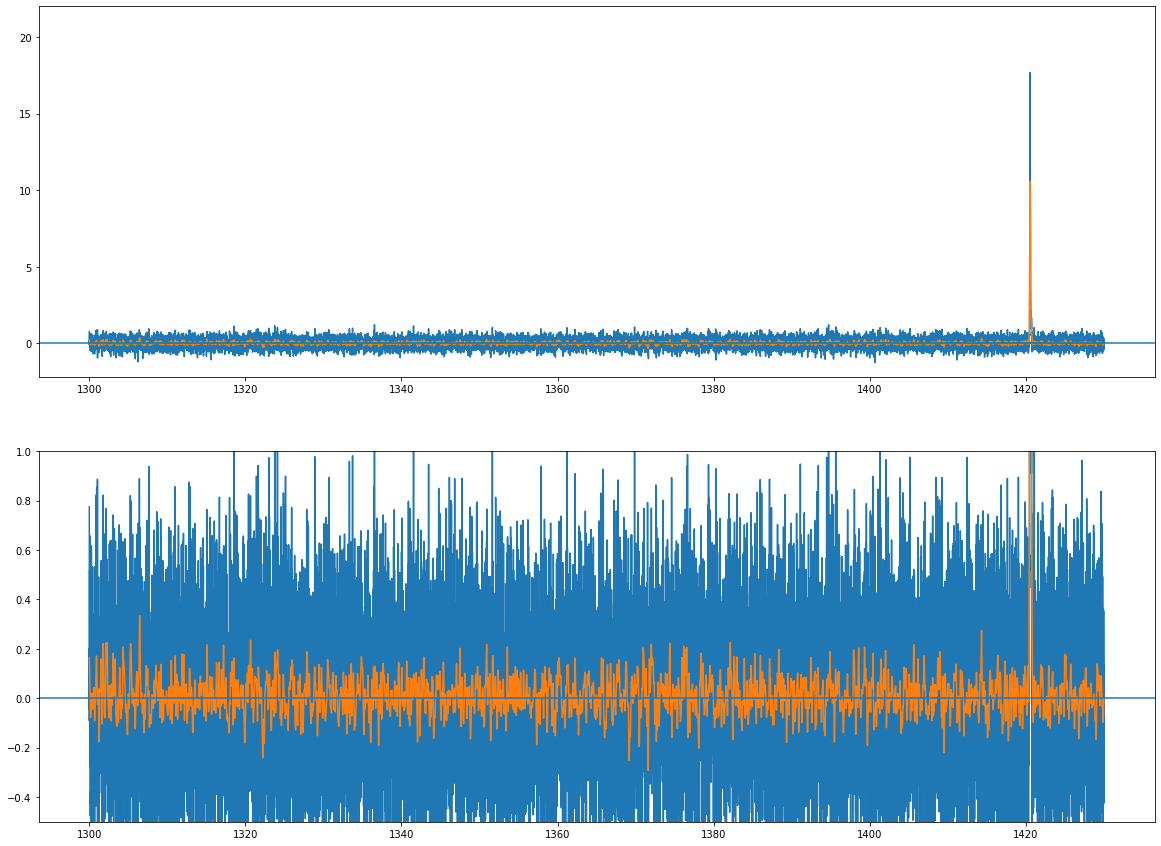

In [ ]:
i = 8
fig, axs = plt.subplots(2, 1, figsize=(20, 15),)

ax = axs[0]
ax.plot(freq, T2p[i, :, 0])
ax.plot(freq, ndimage.gaussian_filter1d(T2p[i, :, 0], 4))
ax.plot(freq, T2p[i, :, 0] - T[i, :, 0])
ax.axhline(y=0)

ax.set_ylim(top=22)
# ax.axhline(y=0)
# ax.set_ylim(-0.5,1)
# ax.set_xlim(1300,1340)

ax = axs[1]
ax.plot(freq, T[i, :, 0])
ax.plot(freq, ndimage.gaussian_filter1d(T[i, :, 0], 5))
ax.axhline(y=0)
ax.set_ylim(-0.5, 1)
# ax.set_xlim(1300,1340)